# Unified XGBoost + Rules Gatekeeper Evaluation

This notebook implements and evaluates a unified **XGBoost Milestone Confidence + Physical Rules** gatekeeper on 1,642 videos from the UCF50 dataset. 

The Gatekeeper uses a series of simple physical checks combined with the milestone classifier predictions to accept or reject videos:
1. **Human Count check**: Reject videos if they have multiple people (e.g. salsa spin, military parade) or 0 people (empty room).
2. **Verticality check**: Reject horizontal orientations (bench press, diving) or upside down postures.
3. **Milestone Timing check**: Verify that the active downswing duration (Top of Backswing to Impact) is between **1 and 25 frames** (accommodating lower framerates/tracking jitter).
4. **Confidence check**: Verify that the average peak milestone probability across all 8 milestones is high.

In [ ]:
import os
import sys
import glob
import random
import time
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import precision_recall_curve, auc, average_precision_score, classification_report, confusion_matrix

# Set project root path
PROJECT_ROOT = os.path.abspath("../")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.data_processor import GolfVideoProcessor
from src.feature_engineer import engineer_sliding_window

UCF_DIR = os.path.join(PROJECT_ROOT, "data/UCF50 2")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "data/processed/ucf_test_features")

--- 

## 📂 1. Precomputing UCF Video Features with New Columns

We gather all Golf Swing videos (True Positives) and sample 1,500 non-golf videos from the other UCF50 categories. We then run them through our modified `GolfVideoProcessor` to generate CSVs containing the new `num_people`, `torso_angle_deg`, and `is_upright` columns.

In [ ]:
def is_video_readable(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return False
    ret, _ = cap.read()
    cap.release()
    return bool(ret)

if os.path.exists(UCF_DIR):
    # 1. Gather all Golf Swing videos
    golf_dir = os.path.join(UCF_DIR, "GolfSwing")
    raw_golf_videos = glob.glob(os.path.join(golf_dir, "*.avi"))
    golf_videos = [p for p in raw_golf_videos if is_video_readable(p)]
    print(f"Readable GolfSwing videos: {len(golf_videos)}")
    
    # 2. Gather all non-golf videos
    all_categories = [d for d in os.listdir(UCF_DIR) if os.path.isdir(os.path.join(UCF_DIR, d))]
    raw_non_golf_videos = []
    for category in all_categories:
        if category == "GolfSwing":
            continue
        cat_dir = os.path.join(UCF_DIR, category)
        videos = glob.glob(os.path.join(cat_dir, "*.avi"))
        raw_non_golf_videos.extend(videos)
        
    non_golf_videos = [p for p in raw_non_golf_videos if is_video_readable(p)]
    print(f"Readable non-golf videos: {len(non_golf_videos)}")
    
    # 3. Sample 1,500 non-golf videos
    random.seed(42)
    sample_size = min(1500, len(non_golf_videos))
    sampled_non_golf_videos = random.sample(non_golf_videos, sample_size)
    
    # Combine and shuffle
    all_tasks = [(p, 1) for p in golf_videos] + [(p, 0) for p in sampled_non_golf_videos]
    random.shuffle(all_tasks)
    print(f"Total videos to precompute: {len(all_tasks)}")
else:
    print(f"Error: UCF50 directory not found at {UCF_DIR}")
    all_tasks = []

In [ ]:
# Re-create output directory empty
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Starting precomputation. This will recreate the CSVs with our new columns...")
start_time = time.time()
success_count = 0
fail_count = 0

for idx, (video_path, is_golf) in enumerate(all_tasks):
    category = os.path.basename(os.path.dirname(video_path))
    filename = os.path.basename(video_path).split('.')[0]
    video_id = f"{category}_{filename}"
    
    # Save using the video filename directly (e.g. v_GolfSwing_g01_c01.csv)
    output_csv_path = os.path.join(OUTPUT_DIR, f"{filename}.csv")
    
    if os.path.exists(output_csv_path):
        success_count += 1
        continue
    
    try:
        with GolfVideoProcessor() as processor:
            df_vid = processor.process_video(video_path, video_id=video_id)
        
        df_vid["is_golf"] = is_golf
        df_vid.to_csv(output_csv_path, index=False)
        success_count += 1
    except Exception as e:
        fail_count += 1
        print(f"ERROR on {category}/{filename}: {e}")
        
    if (idx + 1) % 200 == 0 or idx == len(all_tasks) - 1:
        print(f"Progress: {idx+1}/{len(all_tasks)} | Success: {success_count} | Failed: {fail_count}")

print(f"Precomputation finished in {(time.time() - start_time)/60:.2f} minutes.")

--- 

## ⚡ 2. Combined XGBoost + Rules Gatekeeper Logic

We now define the combined verification function `check_golf_swing_video` which runs the four checks:
1. **Verticality**: Torso angle must be $< 45^\circ$ at address (first 5 frames).
2. **Orientation**: Person must be upright (shoulders above hips) in the first 5 frames.
3. **Timing**: The downswing duration (Top of Backswing to Impact) must be between **1 and 25 frames**.
4. **Confidence**: Average peak milestone probability must be above the decision threshold.

In [5]:
def check_golf_swing_video(df_engineered, xgb_model, threshold=0.20):
    """
    Unified gatekeeper verification using XGBoost milestone confidence + physical rules.
    """
    feature_cols = xgb_model.get_booster().feature_names
    
    # 1. Rule 1: High NaN Density check
    pose_cols = sorted([c for c in df_engineered.columns if c.startswith("norm_")])
    nan_ratio = df_engineered[pose_cols].isna().mean().mean()
    if nan_ratio > 0.4:
        return False, {"status": "REJECTED (High NaN Density)", "score": -1.0}
        
    # 2. Rule 2: Verticality check (Torso angle and orientation)
    # Check verticality and upright orientation at address (first 5 frames)
    mean_torso_angle = df_engineered["torso_angle_deg"].iloc[:min(5, len(df_engineered))].mean()
    mean_upright = df_engineered["is_upright"].iloc[:min(5, len(df_engineered))].mean()
    
    if mean_torso_angle > 45.0 or mean_upright < 0.5:
        return False, {
            "status": "REJECTED (Failed Verticality)", 
            "score": -1.0,
            "torso_angle": mean_torso_angle,
            "is_upright": mean_upright
        }
        
    # 3. Rule 3: Number of humans check
    # Average number of detected people should be around 1 (reject empty or crowded frames)
    mean_people = df_engineered["num_people"].mean()
    if not (0.5 <= mean_people <= 1.5):
        return False, {
            "status": "REJECTED (Failed Human Count)", 
            "score": -1.0, 
            "mean_people": mean_people
        }
        
    # 4. XGBoost Inference & Peak Extraction
    # Prepare dummy categorical columns
    df_temp = df_engineered.copy()
    df_temp["view"] = pd.Categorical(["face-on"] * len(df_temp), categories=['down-the-line', 'face-on', 'other'])
    df_temp["sex"] = pd.Categorical(["m"] * len(df_temp), categories=['f', 'm'])
    df_temp["club"] = pd.Categorical(["driver"] * len(df_temp), categories=['driver', 'iron', 'fairway', 'wedge', 'hybrid'])
    
    probs = xgb_model.predict_proba(df_temp[feature_cols])
    
    milestones = []
    peak_probs = []
    start_frame = 0
    for c in range(1, 9):
        search_window = probs[start_frame:, c]
        if len(search_window) > 0:
            peak_idx = np.argmax(search_window) + start_frame
            peak_prob = probs[peak_idx, c]
        else:
            peak_prob = 0.0
            peak_idx = start_frame
        milestones.append(peak_idx)
        peak_probs.append(peak_prob)
        start_frame = peak_idx + 1
        
    # 5. Rule 4: Swing Timing Check (Downswing: Top to Impact)
    downswing_duration = milestones[4] - milestones[3]
    if not (1 <= downswing_duration <= 25):
        return False, {
            "status": "REJECTED (Failed Swing Timing)", 
            "score": -1.0,
            "downswing_duration": downswing_duration
        }
        
    # 6. Rule 5: Milestone Confidence Threshold
    mean_confidence = np.mean(peak_probs)
    if mean_confidence < threshold:
        return False, {
            "status": "REJECTED (Low milestone confidence)", 
            "score": mean_confidence,
            "peak_probs": peak_probs
        }
        
    return True, {
        "status": "ACCEPTED", 
        "score": mean_confidence,
        "peak_probs": peak_probs
    }

--- 

## 📊 3. Evaluating on the UCF Test Set (1,642 Videos)

We now load the pre-trained milestone classifier and run our unified gatekeeper on all 1,642 videos.

In [6]:
# Load pre-trained milestone classifier
model_path = os.path.join(PROJECT_ROOT, "models/golf_phase_model.json")
xgb_model = xgb.XGBClassifier()
xgb_model.load_model(model_path)

csv_files = sorted(glob.glob(os.path.join(OUTPUT_DIR, "*.csv")))
print(f"Running evaluation over {len(csv_files)} files...")

results = []
for idx, filepath in enumerate(csv_files):
    df_vid = pd.read_csv(filepath)
    if len(df_vid) == 0:
        continue
        
    is_golf = df_vid["is_golf"].iloc[0]
    df_eng = engineer_sliding_window(df_vid)
    
    # Run gatekeeper (use threshold=0.0 to gather scores for the PR curve)
    accepted, diag = check_golf_swing_video(df_eng, xgb_model, threshold=0.0)
    
    results.append({
        "filename": os.path.basename(filepath),
        "is_golf": is_golf,
        "score": diag["score"],
        "status": diag["status"]
    })

df_eval = pd.DataFrame(results)
print("Evaluation complete.")

Running evaluation over 1642 files...
Evaluation complete.


=== GATEKEEPER METRICS ===
Area Under PR Curve (AUC PR): 0.7904
Average Precision (AP):       0.7872
Optimal Threshold (maximizing F1): 0.4712
Max F1-Score: 0.8115 (Precision: 0.9706, Recall: 0.6972)


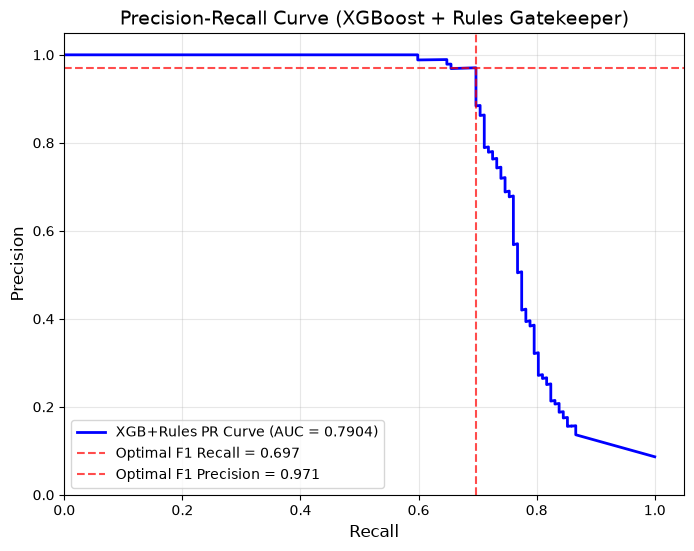

In [7]:
y_true = df_eval["is_golf"].values
y_scores = df_eval["score"].values

precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
auc_pr = auc(recall, precision)
ap_score = average_precision_score(y_true, y_scores)

print(f"=== GATEKEEPER METRICS ===")
print(f"Area Under PR Curve (AUC PR): {auc_pr:.4f}")
print(f"Average Precision (AP):       {ap_score:.4f}")

# Find F1-optimal threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.0

print(f"Optimal Threshold (maximizing F1): {best_threshold:.4f}")
print(f"Max F1-Score: {f1_scores[best_idx]:.4f} (Precision: {precision[best_idx]:.4f}, Recall: {recall[best_idx]:.4f})")

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'XGB+Rules PR Curve (AUC = {auc_pr:.4f})')
plt.axvline(x=recall[best_idx], color='red', linestyle='--', alpha=0.7, label=f'Optimal F1 Recall = {recall[best_idx]:.3f}')
plt.axhline(y=precision[best_idx], color='red', linestyle='--', alpha=0.7, label=f'Optimal F1 Precision = {precision[best_idx]:.3f}')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve (XGBoost + Rules Gatekeeper)', fontsize=14)
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])
plt.show()

In [8]:
# Report at target Recall-First threshold of 0.20
target_threshold = 0.20
y_pred_target = (y_scores >= target_threshold).astype(int)

print(f"=== CLASSIFICATION REPORT AT TARGET THRESHOLD ({target_threshold:.2f}) ===\n")
print(classification_report(y_true, y_pred_target, target_names=["Non-Golf", "Golf"]))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_target))

=== CLASSIFICATION REPORT AT TARGET THRESHOLD (0.20) ===

              precision    recall  f1-score   support

    Non-Golf       0.98      0.92      0.95      1500
        Golf       0.47      0.77      0.58       142

    accuracy                           0.90      1642
   macro avg       0.72      0.85      0.76      1642
weighted avg       0.93      0.90      0.91      1642

Confusion Matrix:
[[1374  126]
 [  32  110]]
